In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

from common import *
from experiment import *
from data.http import HTTPExperiment
from treatments.picoquic import treatment_map, NETWORK_SETTING as ns

In [2]:
# Small helper: shorten GE labels for x-axis
def short_ge_name(ge_string: str) -> str:
    # ge_string format: "p,r,bad,good"
    p, r, bad, good = [x.strip() for x in ge_string.split(",")]
    return f"P{p}/R{r}\nBad{bad}%|Good{good}%"

# Consistent bar positions
def grouped_bar_positions(num_groups, num_series, bar_width=0.14, group_gap=0.28):
    """Return x positions for each series in each group and the group centers."""
    centers = np.arange(num_groups) * (num_series * bar_width + group_gap)
    series_offsets = ((np.arange(num_series) - (num_series - 1) / 2.0) * bar_width)
    xs = [centers + off for off in series_offsets]
    return xs, centers

In [35]:
TREATMENT_NAME_TO_LABEL = {
    "End-to-End": "picoquic",
    "Tunnel (Ordered)": "picoquic_rtunnel_retx7_ordered32",
    "Tunnel (Unordered)": "picoquic_rtunnel_retx7",
    "Packrat (no delay)": "picoquic_iblt_0ms",
    "Packrat": "picoquic_iblt_30ms",
}

TREATMENT_ORDER = [
    "End-to-End",
    "Tunnel (Ordered)",
    "Tunnel (Unordered)",
    "Packrat (no delay)",
    "Packrat",
]

TREATMENT_NAME_TO_LABEL_BBR = { k: v + '_bbr' for k, v in TREATMENT_NAME_TO_LABEL.items() }

def TREATMENTS_FOR_GE():
    return [treatment_map(TREATMENT_NAME_TO_LABEL[name]) for name in TREATMENT_ORDER]

def TREATMENTS_FOR_GE_BBR():
    return [treatment_map(TREATMENT_NAME_TO_LABEL_BBR[name]) for name in TREATMENT_ORDER]

In [4]:
# Pick 4 representative GE regimes (percentages, as netem expects):
# - "Bursty-heavy": higher chance to enter bad state & high bad loss
# - "Bursty-light": moderate bursts, modest bad loss
# - "Rare-bursts": rarely go bad, but still painful when it happens
# - "Mostly-good-noisy": almost always good, small good-loss

'''
GE_SCENARIOS = [
    {"name": "Good link", "ge": "0,100,5,20"},
    {"name": "Medium link", "ge": "0,100,10,20"},
    {"name": "Poor link", "ge": "0,100,15,20"},
]
'''

# P%,R%,BAD_LOSS%,GOOD_LOSS%'
GE_SCENARIOS = [
    {"name": "Scenario 1", "ge": "0.2,3,80,2"},
]

def NETWORK_SETTINGS_GE(
    scenarios=GE_SCENARIOS,
    bw1=ns.get('bw1'), bw2=ns.get('bw2'),
    delay1=ns.get('delay1'), delay2=ns.get('delay2')
):
    # We pass ge=..., and neutralize IID fields (loss1/loss2 not used when ge is set)
    nets = []
    for sc in scenarios:
        nets.append(
            NetworkSetting(
                bw1=bw1, bw2=bw2,
                delay1=delay1, delay2=delay2,
                loss1='0', loss2='0',
                ge=sc["ge"],
                qdisc=ns.get('qdisc'),
                jitter1=ns.get('jitter1'),
                jitter2=ns.get('jitter2'),
            )
        )
    return nets


In [5]:
# Helpers mirrored from your prior notebook

def collect_loss_vs_metric_data(
    treatments,
    network_settings,
    data_size,
    n=10,
    max_networks=None,
    execute=False,
    min_i=1,
):
    """
    Runs an HTTPExperiment sweeping network_settings for a single data_size.

    - If execute=True, iteratively runs from min_i..n (so you can reuse partial runs);
      the return value is the RawData from the last iteration (with n trials).
    - If execute=False, it only materializes at n (no execution).
    """
    if execute:
        num_trials_range = range(min_i, n + 1)
    else:
        num_trials_range = [n]

    raw_data = None
    for i in num_trials_range:
        exp = HTTPExperiment(
            num_trials=i,
            treatments=treatments,
            network_settings=network_settings,
            data_sizes=[data_size],
        )
        raw_data = exp.to_raw_data(execute=execute, max_networks=max_networks)
    return raw_data


def collect_data_size_vs_throughput_data(
    treatments,
    network_setting,
    data_sizes,
    n=10,
    max_data_sizes=None,
    execute=False,
    min_i=1,
):
    """
    Kept for parity with your old notebook (not used by the GE bar plot).
    """
    if execute:
        num_trials_range = range(min_i, n + 1)
    else:
        num_trials_range = [n]

    raw_data = None
    for i in num_trials_range:
        exp = HTTPExperiment(
            num_trials=i,
            treatments=treatments,
            network_settings=[network_setting],
            data_sizes=data_sizes,
        )
        raw_data = exp.to_raw_data(execute=execute, max_data_sizes=max_data_sizes)
    return raw_data


In [6]:
def DATA_SIZE(bottleneck_bw=20, time_s=10):
    # bytes to send; 20 Mbps for 10s, like your existing notebook
    return bottleneck_bw * 250000 * time_s

DATA_SIZES = [DATA_SIZE(bottleneck_bw=20, time_s=10)]

# Max concurrent networks per treatment (kept conservative; tune if you know your infra)
max_networks = {
    TREATMENT_NAME_TO_LABEL["End-to-End"]: 7,
    TREATMENT_NAME_TO_LABEL["Tunnel (Ordered)"]: 18,
    TREATMENT_NAME_TO_LABEL["Tunnel (Unordered)"]: 14,
    TREATMENT_NAME_TO_LABEL["Packrat (no delay)"]: 18,
    TREATMENT_NAME_TO_LABEL["Packrat"]: 18,
}

# Some benchmarks enforce data-size ceilings (optional; keep if you use elsewhere)
max_data_sizes = {
    TREATMENT_NAME_TO_LABEL["End-to-End"]: 10000000,
}


In [23]:
# Toggle execute=True to actually run. n is the number of trials (median + IQR).
RUN_EXECUTE = True
NUM_TRIALS = 10
MIN_TRIALS_TO_START = 1

treatments = TREATMENTS_FOR_GE()
network_settings = NETWORK_SETTINGS_GE()

loss_vs_throughput_data_ge = collect_loss_vs_metric_data(
    n=NUM_TRIALS,
    execute=RUN_EXECUTE,
    treatments=treatments,
    max_networks=max_networks,
    network_settings=network_settings,
    data_size=DATA_SIZE(),
    min_i=MIN_TRIALS_TO_START,
)

# This prints a quick index of networks so you can see the GE strings
# Prints a quick index of networks and their GE strings
for net_obj in network_settings:
    print(net_obj.get('ge'))

0.2,3,80,2


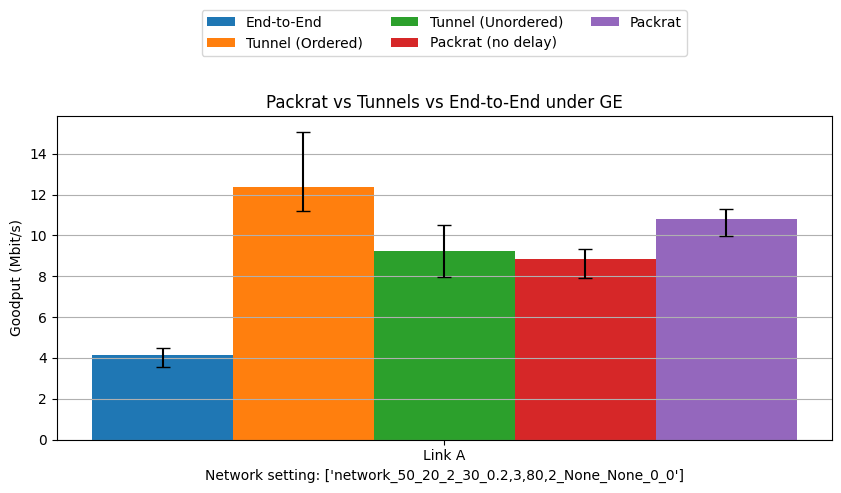

In [45]:
def plot_ge_vs_throughput_bars(raw_data, title=None, pdf=None, style=False, name_to_label=TREATMENT_NAME_TO_LABEL):
    data = raw_data.to_plottable_data('throughput_mbps')

    # Build x-axis (GE scenarios) in the same order as provided
    exp = raw_data.exp
    net_labels = data.network_settings  # verbose labels
    # Map them to our GE_SCENARIOS order by matching 'ge' string
    ge_to_name = { sc["ge"]: sc["name"] for sc in GE_SCENARIOS }

    # Prepare category order
    cat_order = []
    cat_order_verbose = []
    for net_label in net_labels:
        ns_obj = exp.get_network_setting(net_label)
        ge_string = ns_obj.get('ge')
        if ge_string in ge_to_name:
            cat_order.append(ge_to_name[ge_string])
            cat_order_verbose.append(net_label)
        else:
            # Fallback: keep unknowns but make a short name
            cat_order.append(short_ge_name(ge_string))
            cat_order_verbose.append(net_label)

    # Series order = treatments in TREATMENT_ORDER
    series_labels = TREATMENT_ORDER

    # Collect y values: median and IQR for each (series, category)
    med = { s: [] for s in series_labels }
    low = { s: [] for s in series_labels }
    high = { s: [] for s in series_labels }

    delta = 25  # IQR: 25th to 75th
    for idx, cat in enumerate(cat_order):
        net_label_verbose = cat_order_verbose[idx]
        for s in series_labels:
            label_key = name_to_label[s]
            # If missing (e.g., run didn't complete), put NaN
            if net_label_verbose not in data.data[label_key]:
                med[s].append(np.nan)
                low[s].append(0.0)
                high[s].append(0.0)
                continue
            per_size = data.data[label_key][net_label_verbose]
            # There's only one data size here; get its PlotStats
            data_size = data.data_sizes[0]
            if data_size not in per_size:
                med[s].append(np.nan)
                low[s].append(0.0)
                high[s].append(0.0)
                continue

            stats = per_size[data_size]
            m = stats.p(50)
            l = m - stats.p(50 - delta)
            h = stats.p(50 + delta) - m
            med[s].append(m)
            low[s].append(l)
            high[s].append(h)

    # Plot grouped bars
    num_groups = len(cat_order)
    num_series = len(series_labels)
    bar_width = 0.14
    xs, centers = grouped_bar_positions(num_groups, num_series, bar_width=bar_width, group_gap=0.28)

    plt.figure(figsize=(10, 4.2))
    plotted_labels = []
    for si, s in enumerate(series_labels):
        vals = med[s]
        el = low[s]
        eh = high[s]
        # If you have STYLE/LABEL_MAP and want fancier styling, you can use it here.
        b = plt.bar(xs[si], vals, yerr=[el, eh], width=bar_width, label=s, capsize=5)
        plotted_labels.append(s)

    # Axis & legend
    plt.xticks(
        centers,
        [f"Link {chr(65 + i)}" for i in range(len(cat_order))]
    )
    if title is None:
        title = f"Goodput vs GE Loss Model — {data_size_str(data.data_sizes[0])}"
    plt.title(title)
    plt.ylabel("Goodput (Mbit/s)")
    plt.xlabel(f"Network setting: {raw_data.exp.network_settings}")
    plt.grid(axis='y')
    plt.ylim(0)  # start at zero
    plot_title_and_legend(title, plotted_labels, base_height=1.20, row_height=0.07, title_height=0.08, ncol=3)

    if pdf:
        save_pdf(pdf)
    plt.show()

# Plot
plot_ge_vs_throughput_bars(loss_vs_throughput_data_ge, title="Packrat vs Tunnels vs End-to-End under GE")


In [38]:
treatments_bbr = TREATMENTS_FOR_GE_BBR()

NUM_TRIALS_BBR = 20

loss_vs_throughput_data_ge_bbr = collect_loss_vs_metric_data(
    n=NUM_TRIALS_BBR,
    execute=RUN_EXECUTE,
    treatments=treatments_bbr,
    max_networks=max_networks,
    network_settings=network_settings,
    data_size=DATA_SIZE(),
    min_i=MIN_TRIALS_TO_START,
)

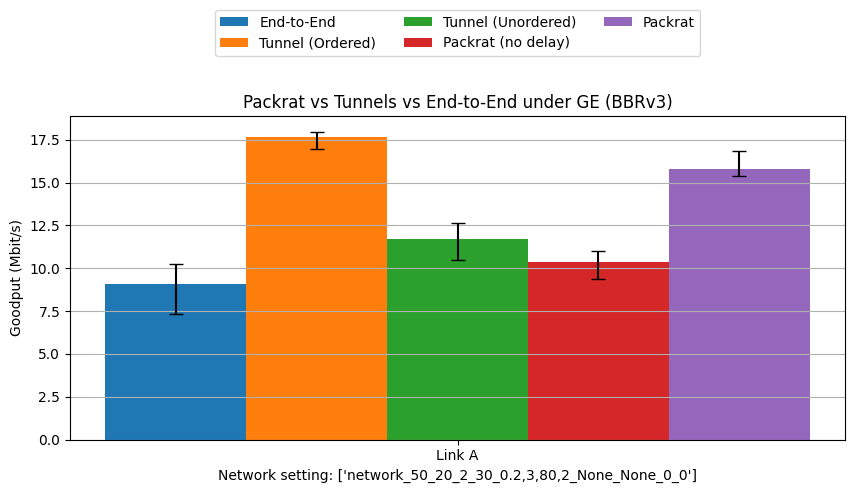

In [46]:
plot_ge_vs_throughput_bars(loss_vs_throughput_data_ge_bbr, title="Packrat vs Tunnels vs End-to-End under GE (BBRv3)", name_to_label=TREATMENT_NAME_TO_LABEL_BBR)

'network_50_20_2_30_0.2,3,80,2_None_None_0_0'